import

In [21]:
import cv2
import re
import os
import matplotlib.pyplot as plt

from ultralytics import YOLO
from paddleocr import PaddleOCR

config cơ bản

In [ ]:
vehicle_model_path = "models/vehicle.pt"
plate_model_path = "models/bienso.pt"
video_path = "videos/sample.mp4"
CLASS_NAMES = {
    0: "bus",
    1: "car",
    2: "motor",
    3: "truck"
}

VEHICLE_CONF = 0.30
PLATE_CONF = 0.15
PLATE_IMGSZ = 1280

hàm load model

In [23]:
def load_models(vehicle_model_path, plate_model_path):
    vehicle_model = YOLO(vehicle_model_path)
    plate_model = YOLO(plate_model_path)

    ocr = PaddleOCR(
        use_doc_orientation_classify=False,
        use_doc_unwarping=False,
        use_textline_orientation=False,
        lang="en"
    )

    return vehicle_model, plate_model, ocr

hàm box cơ bản

In [24]:
def box_area(box):
    x1, y1, x2, y2 = box
    return max(0, x2 - x1) * max(0, y2 - y1)


def center_of_box(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) // 2, (y1 + y2) // 2)


def point_in_box(point, box):
    px, py = point
    x1, y1, x2, y2 = box
    return x1 <= px <= x2 and y1 <= py <= y2

hàm ghép plate -> vehicle

In [25]:
def assign_plate_to_vehicle(plate_box, vehicles):
    cx, cy = center_of_box(plate_box)
    candidates = []

    for v in vehicles:
        vx1, vy1, vx2, vy2 = v["box"]

        # tâm biển số phải nằm trong box xe
        if not point_in_box((cx, cy), v["box"]):
            continue

        # ưu tiên biển số ở nửa dưới của xe
        vehicle_h = vy2 - vy1
        if cy < vy1 + 0.35 * vehicle_h:
            continue

        candidates.append(v)

    if not candidates:
        return None

    # nếu nhiều xe cùng chứa plate, chọn xe có box nhỏ hơn
    return min(candidates, key=lambda v: box_area(v["box"]))

hàm detect xe

In [26]:
def detect_vehicles(frame, vehicle_model):
    results = vehicle_model.predict(
        frame,
        conf=VEHICLE_CONF,
        verbose=False
    )

    vehicles = []

    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])

            if cls_id not in CLASS_NAMES:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            vehicles.append({
                "class_id": cls_id,
                "class_name": CLASS_NAMES[cls_id],
                "conf": conf,
                "box": (x1, y1, x2, y2),
                "plate_box": None,
                "plate_conf": 0.0,
                "plate_text": ""
            })

    return vehicles

hàm detect biển số

In [27]:
def detect_plates(frame, plate_model):
    results = plate_model.predict(
        frame,
        conf=PLATE_CONF,
        imgsz=PLATE_IMGSZ,
        verbose=False
    )

    plates = []

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])

            plates.append({
                "box": (x1, y1, x2, y2),
                "conf": conf
            })

    return plates

hàm ghép plate vào vehicle

In [28]:
def match_plates_to_vehicles(vehicles, plates):
    # reset
    for v in vehicles:
        v["plate_box"] = None
        v["plate_conf"] = 0.0

    # gan tung plate vao xe
    for p in plates:
        matched_vehicle = assign_plate_to_vehicle(p["box"], vehicles)

        if matched_vehicle is None:
            continue

        # neu xe chua co plate -> gan luon
        if matched_vehicle["plate_box"] is None:
            matched_vehicle["plate_box"] = p["box"]
            matched_vehicle["plate_conf"] = p["conf"]
        else:
            # neu da co roi -> giu plate co conf cao hon
            if p["conf"] > matched_vehicle["plate_conf"]:
                matched_vehicle["plate_box"] = p["box"]
                matched_vehicle["plate_conf"] = p["conf"]

    return vehicles

hàm preprocess biển số

In [29]:
def preprocess_plate(plate_img):
    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)

    gray = cv2.resize(
        gray,
        None,
        fx=2,
        fy=2,
        interpolation=cv2.INTER_CUBIC
    )

    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    _, th = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return th

hàm làm sạch text OCR

In [30]:
def clean_plate_text(text):
    text = text.upper().strip()
    text = re.sub(r"\s+", "", text)          # bỏ khoảng trắng
    text = re.sub(r"[^A-Z0-9\-.]", "", text) # chỉ giữ A-Z, 0-9, -, .
    return text

hàm OCR từ plate_box

In [31]:
def ocr_plate_from_box(frame, plate_box, ocr, temp_path="temp_plate.jpg"):
    x1, y1, x2, y2 = plate_box

    # chặn biên
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(frame.shape[1], x2)
    y2 = min(frame.shape[0], y2)

    # crop
    plate_crop = frame[y1:y2, x1:x2].copy()
    if plate_crop.size == 0:
        return ""

    # preprocess
    plate_proc = preprocess_plate(plate_crop)

    # lưu tạm để OCR
    cv2.imwrite(temp_path, plate_proc)

    # OCR
    result = ocr.predict(temp_path)

    if not result or len(result) == 0:
        return ""

    item = result[0]

    texts = item["rec_texts"] if "rec_texts" in item else []
    scores = item["rec_scores"] if "rec_scores" in item else []

    filtered_texts = []
    for txt, score in zip(texts, scores):
        if score >= 0.5:
            filtered_texts.append(clean_plate_text(txt))

    final_text = "".join(filtered_texts)
    return final_text

hàm vẽ kết quả cuối

In [32]:
def draw_results(frame, vehicles):
    out = frame.copy()

    for v in vehicles:
        x1, y1, x2, y2 = v["box"]

        # ve box xe
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # ve box bien so neu co
        if v["plate_box"] is not None:
            px1, py1, px2, py2 = v["plate_box"]
            cv2.rectangle(out, (px1, py1), (px2, py2), (255, 0, 0), 2)

        # label
        if v["plate_text"]:
            label = f'{v["class_name"]} | {v["plate_text"]}'
        elif v["plate_box"] is not None:
            label = f'{v["class_name"]} | plate'
        else:
            label = f'{v["class_name"]} | no_plate'

        cv2.putText(
            out,
            label,
            (x1, max(30, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

    return out

hàm process_frame(...)

In [33]:
def process_frame(frame, vehicle_model, plate_model, ocr):
    # 1. detect vehicles
    vehicles = detect_vehicles(frame, vehicle_model)

    # 2. detect plates
    plates = detect_plates(frame, plate_model)

    # 3. match plates -> vehicles
    vehicles = match_plates_to_vehicles(vehicles, plates)

    # 4. OCR cho các xe có plate
    for v in vehicles:
        v["plate_text"] = ""

        if v["plate_box"] is not None:
            v["plate_text"] = ocr_plate_from_box(frame, v["plate_box"], ocr)

    # 5. draw output
    out = draw_results(frame, vehicles)

    return out, vehicles, plates

hàm chạy video live

In [34]:
def run_video_live(
    video_path,
    vehicle_model,
    plate_model,
    ocr,
    save_output=False,
    output_path="output_live.mp4"
):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Khong mo duoc video:", video_path)
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = None
    if save_output:
        writer = cv2.VideoWriter(
            output_path,
            cv2.VideoWriter_fourcc(*"mp4v"),
            fps,
            (w, h)
        )

    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        out_frame, vehicles, plates = process_frame(
            frame,
            vehicle_model,
            plate_model,
            ocr
        )

        cv2.imshow("Vehicle + Plate + OCR", out_frame)

        if writer is not None:
            writer.write(out_frame)

        frame_count += 1
        if frame_count % 10 == 0:
            print(f"processed: {frame_count}")

        key = cv2.waitKey(1) & 0xFF
        if key == 27 or key == ord("q"):   # ESC hoặc q
            break

    cap.release()

    if writer is not None:
        writer.release()

    cv2.destroyAllWindows()
    print("Done")

In [36]:
vehicle_model, plate_model, ocr = load_models(
    vehicle_model_path,
    plate_model_path
)

print("Load vehicle model: OK")
print("Load plate model: OK")
print("Load OCR: OK")

c:\Users\PC\anaconda3\envs\Python_3_10\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC\.paddlex\official_models\en_PP-OCRv5_mobile_rec`.


Load vehicle model: OK
Load plate model: OK
Load OCR: OK


In [38]:
run_video_live(
    video_path,
    vehicle_model,
    plate_model,
    ocr,
    save_output=False
)

processed: 10
processed: 20
processed: 30
processed: 40
processed: 50
processed: 60
processed: 70
processed: 80
Done


(np.float64(-0.5), np.float64(2564.5), np.float64(1495.5), np.float64(-0.5))

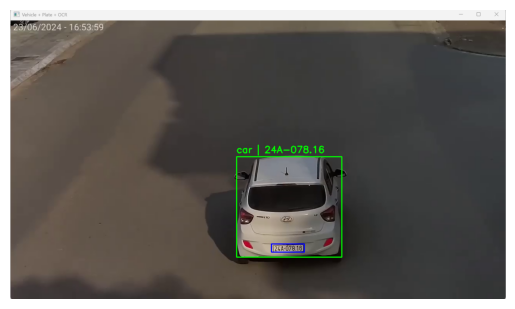

In [40]:
import cv2
import matplotlib.pyplot as plt

path = r"C:\Users\PC\Pictures\Screenshots\Screenshot 2026-03-10 134351.png"

img = cv2.imread(path)                     # đọc ảnh
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # đổi BGR -> RGB

plt.imshow(img)
plt.axis("off")